## Predicting Floods in Sub-Saharan Africa Using Satellite Imagery and Computer Vision

# Project Objective

Developing a machine learning system that can predict floods 3 days in advance in Sub-Saharan Africa using Satellite imagery and related environmental data. The focus will be on demonstrating the application of computer vision techniques to extract spatial patterns predictive of flooding


# Motivation

- Floods are a major hazard in Sub-Saharan Africa, causing property damage, displacement, and loss of life.
- Early prediction enables disaster preparedness and humanitarian response.
- Satellite imagery is increasingly available, offering a rich visual dataset for flood prediction.
- This project demonstrates the use of computer vision pipelines in a real-world social-impact context.


# Classical baseline: Water Inference

In [2]:
# Load necessary libraries

# Core
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import geemap

# Geospatial + raster
import rasterio
from rasterio.plot import show
import geopandas as gpd
import ee
import ml4floods
from ml4floods.data import worldfloods
from georeader import window_utils
from shapely.geometry import box
from ml4floods.visualization import plot_utils
from georeader import plot
from georeader.rasterio_reader import RasterioReader
from ml4floods.data.worldfloods.configs import BANDS_S2, COLORS_WORLDFLOODS

# Notebook display
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports loaded.")


Imports loaded.


## NDWI (Normalized Difference Water Index) + Otsu's Thresholding

1. Feature Extraction (NDWI): Calculate specific ratio of the green and near-infrared (NIR) bands. Water has high reflectance in Green and almost zero in NIR
2. Classification (Otsu's Method): Otsu's Thresholding to automatically calculate the optimal threshold in the NDWI histogram to separate the "Water" peak from the "Land" peak

In [3]:
# Load data

DATA_ROOT = Path("/Volumes/Munashe/WorldFloodsv2")

print("DATA_ROOT:", DATA_ROOT)
print("Contents:", [p.name for p in DATA_ROOT.iterdir()])

DATA_ROOT: /Volumes/Munashe/WorldFloodsv2
Contents: ['.cache', 'test', 'README.md', '.gitattributes', 'dataset_metadata.csv', 'train', '._README.md', '.Rhistory', '._.Rhistory']


In [4]:
# Prepare NDWI + Otsu pipeline: discover test S2/GT pairs and define helper functions
from rasterio.warp import reproject, Resampling

TEST_S2_DIR = DATA_ROOT / "test" / "S2"
TEST_GT_DIR = DATA_ROOT / "test" / "gt"

# Find matching test S2 files that have a corresponding GT (robust: exact match or EMSR-prefix)
test_s2_files = sorted(TEST_S2_DIR.glob("*.tif")) if TEST_S2_DIR.exists() else []
matched_pairs = []
for s in test_s2_files:
    candidate_gt = TEST_GT_DIR / f"{s.stem}.tif"
    if candidate_gt.exists():
        matched_pairs.append((s, candidate_gt))
    else:
        prefix = s.stem.split("_")[0]
        cand = sorted(TEST_GT_DIR.glob(f"{prefix}*.tif")) if TEST_GT_DIR.exists() else []
        if cand:
            matched_pairs.append((s, cand[0]))

if not matched_pairs:
    raise RuntimeError("No test S2/GT pairs found in test folder")

# Limit for quick runs; change as needed
samples = matched_pairs[:5]
print(f"Running NDWI+Otsu on {len(samples)} test samples")
print("Sample pairs:", [ (p[0].name, p[1].name) for p in samples ])

Running NDWI+Otsu on 5 test samples
Sample pairs: [('EMSR264_08VATOMANDRY_DEL_v2.tif', 'EMSR264_08VATOMANDRY_DEL_v2.tif'), ('EMSR264_18MIANDRIVAZODETAIL_DEL_v2.tif', 'EMSR264_18MIANDRIVAZODETAIL_DEL_v2.tif'), ('EMSR273_01GRILE_DEL_MONIT04_v2.tif', 'EMSR273_01GRILE_DEL_MONIT04_v2.tif'), ('EMSR286_08ITUANGONORTH_DEL_MONIT02_v1.tif', 'EMSR286_08ITUANGONORTH_DEL_MONIT02_v1.tif'), ('EMSR286_09ITUANGOSOUTH_DEL_MONIT02_v1.tif', 'EMSR286_09ITUANGOSOUTH_DEL_MONIT02_v1.tif')]


In [5]:

# Helper: Otsu threshold implementation (1D) - robust to constant arrays
def otsu_threshold(arr, nbins=256):
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        return 0.0
    # handle constant arrays
    if np.nanmin(arr) == np.nanmax(arr):
        return float(np.nanmin(arr))
    hist, bin_edges = np.histogram(arr, bins=nbins, range=(np.nanmin(arr), np.nanmax(arr)))
    prob = hist.astype(float) / hist.sum()
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    weight1 = np.cumsum(prob)
    mean1 = np.cumsum(prob * bin_centers)
    mean_total = mean1[-1]
    denom = weight1 * (1.0 - weight1)
    denom[denom == 0] = 1e-12
    between = (mean_total * weight1 - mean1) ** 2 / denom
    idx = int(np.nanargmax(between))
    return float(bin_centers[idx])


# Helper: align GT raster to S2 grid (returns aligned array and original nodata value)
def align_gt_to_s2(gt_path, s2_shape, s2_transform, s2_crs):
    with rasterio.open(gt_path) as src_gt:
        gt = src_gt.read(1).astype('int32')
        src_transform = src_gt.transform
        src_crs = src_gt.crs
        gt_nodata = src_gt.nodata

    if gt.shape != s2_shape or src_crs != s2_crs:
        dst_fill = gt_nodata if gt_nodata is not None else 0
        dst = np.full(s2_shape, dst_fill, dtype=gt.dtype)
        reproject(
            source=gt,
            destination=dst,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=s2_transform,
            dst_crs=s2_crs,
            resampling=Resampling.nearest,
        )
        gt_aligned = dst
    else:
        gt_aligned = gt

    return gt_aligned, gt_nodata

In [7]:
# Process each sample: compute NDWI, Otsu threshold, align GT, compute metrics, and visualize

# Use a small pure-numpy implementation for precision and recall.

def precision_recall_from_binary(y_true, y_pred):
    # y_true and y_pred are 1D integer arrays of 0/1
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

for s2_path, gt_path in samples:
    print('\nProcessing:', s2_path.name)

    # Open S2 and read Green (B3) and NIR (B8) using BANDS_S2 mapping
    b3_idx = BANDS_S2.index('B3') + 1
    b8_idx = BANDS_S2.index('B8') + 1

    with rasterio.open(s2_path) as src_s2:
        green = src_s2.read(b3_idx).astype('float32')
        nir = src_s2.read(b8_idx).astype('float32')
        s2_crs = src_s2.crs
        s2_transform = src_s2.transform
        s2_shape = (src_s2.height, src_s2.width)

    # Normalize reflectance using definitive scale
    scale = 3500.0
    green = green / scale
    nir = nir / scale

    # Compute NDWI safely
    denom = (green + nir)
    denom_safe = np.where(denom == 0, np.nan, denom)
    ndwi = (green - nir) / denom_safe

    # Align GT to S2 grid
    gt_aligned, gt_nodata = align_gt_to_s2(gt_path, s2_shape, s2_transform, s2_crs)

    # Determine GT water classes: definitive mapping (labels 1 and 3 represent water)
    gt_water = np.isin(gt_aligned, [1, 3])

    # Compute Otsu threshold on valid NDWI pixels
    valid_mask = ~np.isnan(ndwi)
    ndwi_valid = ndwi[valid_mask]
    if ndwi_valid.size == 0:
        print('No valid NDWI pixels for', s2_path.name)
        continue
    thresh = otsu_threshold(ndwi_valid)
    pred_water = np.zeros_like(ndwi, dtype=bool)
    pred_water[valid_mask] = ndwi[valid_mask] >= thresh

    # Compute metrics where GT is not nodata (treat gt_nodata as invalid if set)
    if gt_nodata is not None:
        gt_mask_for_metrics = gt_aligned != gt_nodata
    else:
        gt_mask_for_metrics = np.ones_like(gt_aligned, dtype=bool)

    common_mask = valid_mask & gt_mask_for_metrics
    if common_mask.sum() == 0:
        print('No overlapping valid pixels for metrics')
        iou = precision = recall = np.nan
    else:
        y_true = gt_water[common_mask].astype(int).ravel()
        y_pred = pred_water[common_mask].astype(int).ravel()
        intersection = np.logical_and(y_true == 1, y_pred == 1).sum()
        union = np.logical_or(y_true == 1, y_pred == 1).sum()
        iou = intersection / union if union > 0 else np.nan
        precision, recall = precision_recall_from_binary(y_true, y_pred)

    print(f'Otsu threshold: {thresh:.4f} | IoU: {iou:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}')


Processing: EMSR264_08VATOMANDRY_DEL_v2.tif
Otsu threshold: -0.1334 | IoU: 0.3992 | Precision: 0.6243 | Recall: 0.5255

Processing: EMSR264_18MIANDRIVAZODETAIL_DEL_v2.tif
Otsu threshold: -0.1334 | IoU: 0.3992 | Precision: 0.6243 | Recall: 0.5255

Processing: EMSR264_18MIANDRIVAZODETAIL_DEL_v2.tif
Otsu threshold: -0.2288 | IoU: 0.2601 | Precision: 0.8240 | Recall: 0.2754

Processing: EMSR273_01GRILE_DEL_MONIT04_v2.tif
Otsu threshold: -0.2288 | IoU: 0.2601 | Precision: 0.8240 | Recall: 0.2754

Processing: EMSR273_01GRILE_DEL_MONIT04_v2.tif
Otsu threshold: 0.0373 | IoU: 0.3541 | Precision: 1.0000 | Recall: 0.3541

Processing: EMSR286_08ITUANGONORTH_DEL_MONIT02_v1.tif
Otsu threshold: 0.0373 | IoU: 0.3541 | Precision: 1.0000 | Recall: 0.3541

Processing: EMSR286_08ITUANGONORTH_DEL_MONIT02_v1.tif
Otsu threshold: -0.3353 | IoU: 0.1021 | Precision: 0.2259 | Recall: 0.1571

Processing: EMSR286_09ITUANGOSOUTH_DEL_MONIT02_v1.tif
Otsu threshold: -0.3353 | IoU: 0.1021 | Precision: 0.2259 | Recall:

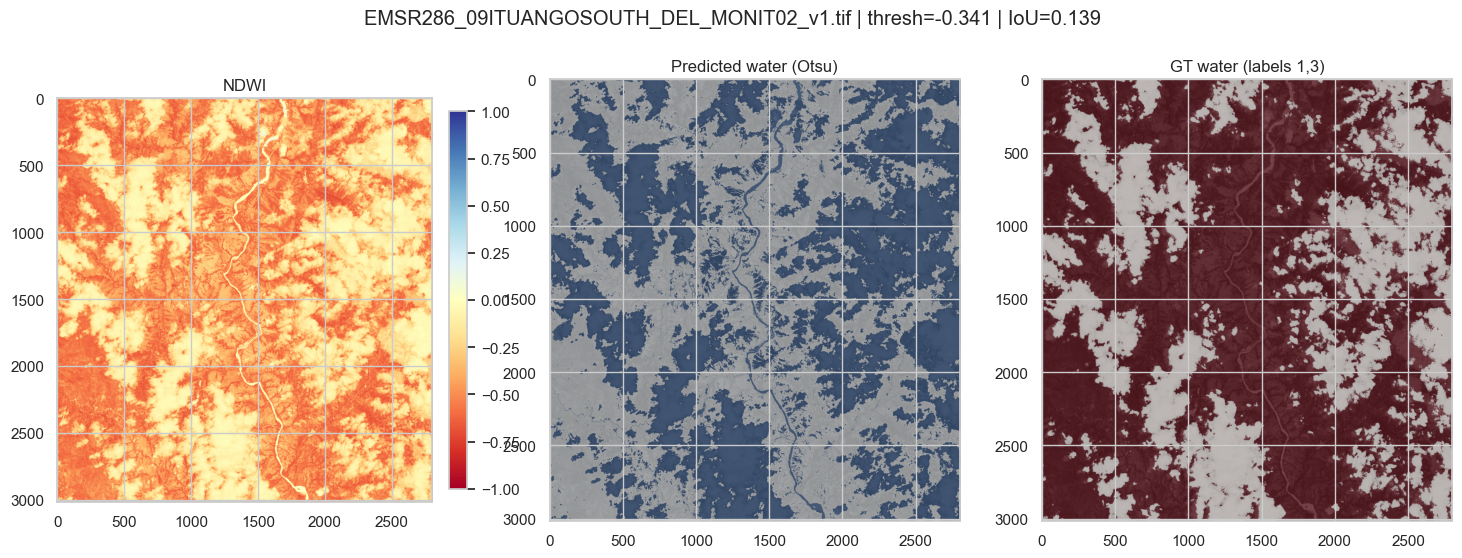

In [8]:
# Visualization: NDWI, Predicted mask, GT overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
im0 = axes[0].imshow(ndwi, cmap='RdYlBu', vmin=-1, vmax=1)
axes[0].set_title('NDWI')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(ndwi, cmap='gray', vmin=-1, vmax=1)
axes[1].imshow(pred_water, cmap='Blues', alpha=0.5)
axes[1].set_title('Predicted water (Otsu)')

axes[2].imshow(ndwi, cmap='gray', vmin=-1, vmax=1)
axes[2].imshow(gt_water, cmap='Reds', alpha=0.5)
axes[2].set_title('GT water (labels 1,3)')

plt.suptitle(f"{s2_path.name} | thresh={thresh:.3f} | IoU={iou:.3f}")
plt.show()